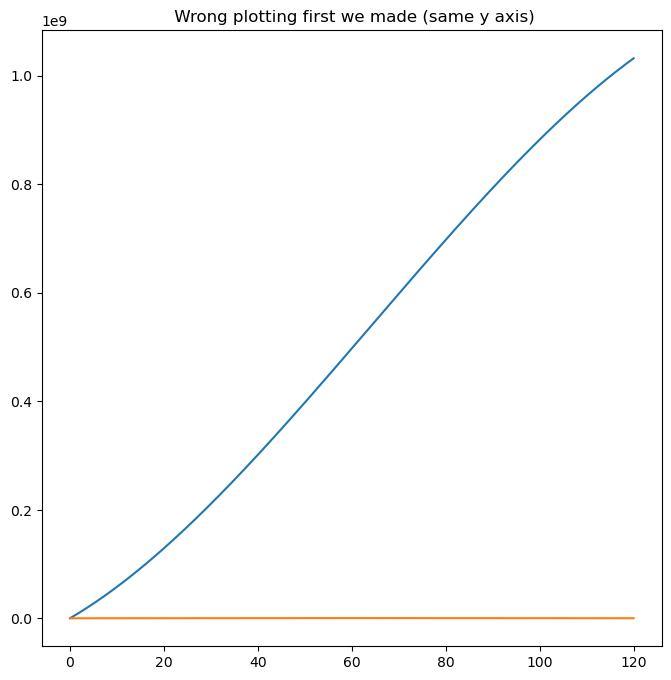

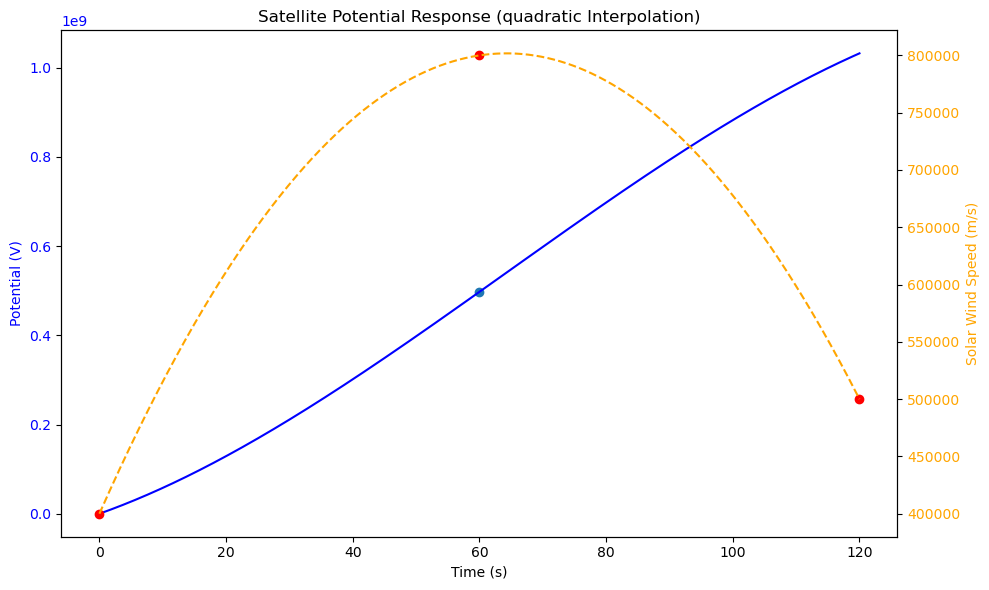

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 데이터 설정 및 보간을 통해 scatter 데이터 (시간에 따른 태양풍 속도 데이터)를 시간에 따른 V의 변화 그래프로 만들어 그리기 
t_data = np.array([0, 60, 120]) # 시간 (초)
v_sw_data = np.array([400000, 800000, 500000]) # m/s 단위로 변환한것  태양품의 속도이며 속도가 커졌다가 작아지는 데이터 요소 3개 

# 여기서 interp1d를 사용하여 f_vsw 함수 만들기 
f_vsw = interp1d(t_data,v_sw_data, kind= 'quadratic') # 기본값이 linear였어서 cubic으로 바꾸어 줄려 했지만 데이터가 4개이상이어야 cubic쓸수 있었음.

# 시뮬레이션 파라미터 정의
dt = 0.1
t_sim = np.arange(0, 120.1, dt)
V = 0.0 # 초기 전위
v_history = []
C_sat = 1e-10 # 위성 정전용량 가정

# 시뮬레이션 루프 구현하기
for t in t_sim:
    # 1. 현재 시간 t에서의 태양풍 속도를 보간 함수에서 가져오기
    current_vsw = f_vsw(t)
    
    # 2. 이온 전류(Ii) 계산 (참고식: I_i = n * e * V_sw * Area 이용)
    e = 1.602e-19 
    cube_sat2 = 0.5 #(큐브위성 지름이 1m라고 치며 반지름은 0.5라고 가정 (구모델 상정)
    area = np.pi * cube_sat2 ** 2 #단면적 원의 넓이 
    n_i = 10**10 # LEO에서 의 이온 전류 밀도는 이정도라고 한다.
    I_i = current_vsw * n_i * area * e
      
    
    # 3. 전자 전류(Ie)
    I_e = -1.5e-8 #대충 I_i랑 비슷하게 놓은것이다. 임의로 만들어낸 상수라고 볼 수 있음.
    
    # 4. 전위 업데이트 코드식 짜기 (dV = I_total / C * dt)
    V += (I_i + I_e) / C_sat *dt
    
    v_history.append(V)

# 시각화 코드짜기 
fig = plt.figure(figsize=(8,8))
plt.plot(t_sim,v_history)
plt.plot(t_data, v_sw_data)
plt.title(" Wrong plotting first we made (same y axis)")
# y축의 범위가 다른데 한번에 plot을 해주어 태양풍 속도가 상수처럼 보인다.(시행착오1) y축이 두개로 만들어야 비교가 가능할 것이다. plt내장함수 twinx()이용!
# 객체 ax1,2을 지정해주자 (도화지에 두축을 상정해 그리기)

# 5. 이중 y축 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))

# 왼쪽 y축: 전위
ax1.plot(t_sim, v_history, color='blue', label='Satellite Potential (V)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Potential (V)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
f_v_history = interp1d(t_sim,v_history)
y = f_v_history(60) # 추가 활용: interp1d함수를 활용해 함수만들어서 변곡점의 점 scatter 해보기 
ax1.scatter(60, y)
# 오른쪽 y축: 태양풍 속도
ax2 = ax1.twinx()
ax2.plot(t_sim, f_vsw(t_sim), color='orange', linestyle='--', label='Solar Wind Speed (m/s)')# (내삽)보간한 점은 다 노란 점선 표시 
ax2.scatter(t_data, v_sw_data, color='red') # 원본 데이터는 빨간 점 표시 
ax2.set_ylabel('Solar Wind Speed (m/s)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Satellite Potential Response (quadratic Interpolation)")
fig.tight_layout() # 이건 그냥 이쁘게 그려주기 위한 코드 식일뿐이다.
plt.show()

In [3]:
'''데이터 분석하기 
태양풍의 속도가 시간이 지날수록 커졌다가 작아지는 과정을 표현한 그래프이다. 가속도의 부호가 바뀌는 지점(t가 60초일때의 빨간점)
이 전위의 그래프에서는 파란점 (변곡점)에 해당한다. 
핵심은 태양풍의 속도가 커졌다가 작아지는 과정에서 전위의 변화는 아래로 볼록하다가 위로 볼록해진다.
따라서 전위의 변곡점이 존재한다.
이는 이차미분 (2nd derivative) 즉 태양풍의 속도에 대한 도함수를  (태양풍의 위치에 대한 이계도함수) 직접 구하면,(우주수치계산에서 배운 미분법 활용)으로 수치적으로도 해석 가능할 것으로 예상된다.
그리고 애초에 위성 전위와 태양풍 속도 사이의 관계식을 보면 위성전위를 미분한 식이 태양풍의 속도와 같다 즉 위성전위의 이차미분이 태양풍의 가속도와 같다는 뜻과 같다.  '''

'데이터 분석하기 \n태양풍의 속도가 시간이 지날수록 커졌다가 작아지는 과정을 표현한 그래프이다. 가속도의 부호가 바뀌는 지점(t가 60초일때의 빨간점)\n이 전위의 그래프에서는 파란점 (변곡점)에 해당한다. \n핵심은 태양풍의 속도가 커졌다가 작아지는 과정에서 전위의 변화는 아래로 볼록하다가 위로 볼록해진다.\n따라서 전위의 변곡점이 존재한다.\n이는 이차미분 (2nd derivative) 즉 태양풍의 속도에 대한 도함수를  (태양풍의 위치에 대한 이계도함수) 직접 구하면,(우주수치계산에서 배운 미분법 활용)으로 수치적으로도 해석 가능할 것으로 예상된다.\n그리고 애초에 위성 전위와 태양풍 속도 사이의 관계식을 보면 위성전위를 미분한 식이 태양풍의 속도와 같다 즉 위성전위의 이차미분이 태양풍의 가속도와 같다는 뜻과 같다.  '

In [4]:
# 수치해석적 검증 (전명원 교수님 수업 복습)
'''이계도함수를 구하면 수치적으로 해석 가능하다"는 부분은 중앙 차분법(Central Difference Method)으로 바로 증명할 수 있어.
코딩으로 검증한다면 아래와 같은 로직
v\history의 변화율을 구함 (1차 미분)
그 변화율의 변화율을 구함 (2차 미분)
2차 미분값이 0이 되는 지점이 정말
$t=60$ 근처인지 확인'''

'이계도함수를 구하면 수치적으로 해석 가능하다"는 부분은 중앙 차분법(Central Difference Method)으로 바로 증명할 수 있어.\n코딩으로 검증한다면 아래와 같은 로직\nv\\history의 변화율을 구함 (1차 미분)\n그 변화율의 변화율을 구함 (2차 미분)\n2차 미분값이 0이 되는 지점이 정말\n$t=60$ 근처인지 확인'

In [20]:
f = f_v_history
x = 60 
def my_f(func,x):
    h = 1e-10
    value = -f(x+2.0*h) + 8.0 * f(x+h) - 8.0*f(x-h) + f(x-2.0*h)
    value = value /(12.0*h)
    return value
print(my_f(f_vsw,60.0))



10066231.09181722


In [33]:
# 1. 시뮬레이션 결과(v_history)를 다시 보간함수로 만들기
f_v_history = interp1d(t_sim, v_history, kind='cubic')

def my_f1(func, x):
    h = 1e-4 # h값을 조금 키워보자
    # 1차 미분 (기울기)
    value = (-func(x + 2*h) + 8*func(x + h) - 8*func(x - h) + func(x - 2*h)) / (12*h)
    return value

# 2차 미분 함수 (이계도함수) - 이게 0이 되어야 변곡점!
def my_f2(func, x):
    h = 1e-4
    # 중앙 차분법을 이용한 2차 미분 공식
    value = (func(x + h) - 2*func(x) + func(x - h)) / (h**2)
    return value

# 확인
print(f"60초에서 속도의 1차 미분(가속도): {my_f1(f_vsw, 60.0)}") 
print(f"60초에서 전위의 2차 미분(변곡성): {my_f2(f_v_history, 60.0)}")


# 60초 전후의 값을 찍어보자
print(f"55초 전위 2차 미분: {my_f2(f_v_history, 55.0)}")
print(f"60초 전위 2차 미분: {my_f2(f_v_history, 60.0)}")
print(f"65초 전위 2차 미분: {my_f2(f_v_history, 65.0)}")

60초에서 속도의 1차 미분(가속도): 833.3333331393077
60초에서 전위의 2차 미분(변곡성): 10365.24772644043
55초 전위 2차 미분: 22596.120834350586
60초 전위 2차 미분: 10365.24772644043
65초 전위 2차 미분: -1871.5858459472656
